In [19]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import timm
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

## FUNCTION

In [12]:
class LowRankSecondOrder(nn.Module):
    def __init__(self, in_dim, proj_dim=128, out_dim=None, use_linear_proj=True):
        super().__init__()
        self.in_dim = in_dim
        self.proj_dim = proj_dim
        self.use_linear_proj = use_linear_proj
        self.V = nn.Linear(in_dim, proj_dim, bias=False)
        if use_linear_proj:
            self.lin = nn.Linear(in_dim, proj_dim)
            out_dim = out_dim or (proj_dim * 2)
        else:
            self.lin = None
            out_dim = out_dim or proj_dim
        self.out_dim = out_dim

    def forward(self, x):
        v = self.V(x)
        second_order = v * v
        if self.lin is not None:
            linear_part = F.gelu(self.lin(x))
            out = torch.cat([linear_part, second_order], dim=-1)
        else:
            out = second_order
        return out

class AttentionOverChunks(nn.Module):
    def __init__(self, embed_dim, num_chunks=8, num_heads=4, attn_dropout=0.0):
        super().__init__()
        assert embed_dim % num_chunks == 0
        self.num_chunks = num_chunks
        self.chunk_dim = embed_dim // num_chunks
        self.mha = nn.MultiheadAttention(embed_dim=self.chunk_dim, num_heads=num_heads,
                                         dropout=attn_dropout, batch_first=False)
        self.ff = nn.Sequential(
            nn.Linear(self.chunk_dim, self.chunk_dim),
            nn.GELU(),
            nn.Linear(self.chunk_dim, self.chunk_dim)
        )

    def forward(self, x):
        b = x.shape[0]
        seq = x.view(b, self.num_chunks, self.chunk_dim).permute(1, 0, 2)
        attn_out, attn_weights = self.mha(seq, seq, seq)
        pooled = attn_out.mean(dim=0)
        out = self.ff(pooled)
        return out, attn_weights

class HybridPolyAttnClassifier(nn.Module):
    def __init__(self, backbone_name='resnet18', pretrained=True, num_classes=5,
                 embed_dim=512, poly_proj_dim=256, num_chunks=8, num_heads=4, dropout=0.2):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained,
                                          num_classes=0, global_pool='avg')
        self.embed_dim = embed_dim or self.backbone.num_features
        self.poly = LowRankSecondOrder(in_dim=self.embed_dim, proj_dim=poly_proj_dim)
        poly_out_dim = self.poly.out_dim
        assert poly_out_dim % num_chunks == 0
        self.attn = AttentionOverChunks(embed_dim=poly_out_dim,
                                        num_chunks=num_chunks, num_heads=num_heads)
        final_dim = poly_out_dim // num_chunks
        self.classifier = nn.Sequential(
            nn.LayerNorm(final_dim),
            nn.Dropout(dropout),
            nn.Linear(final_dim, num_classes)
        )

    def forward(self, x):
        emb = self.backbone(x)
        poly = self.poly(emb)
        attn_out, _ = self.attn(poly)
        logits = self.classifier(attn_out)
        return logits, _


## DATASET

In [4]:
data_dir = "./Data"
models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
num_epochs = 30
lr = 2e-4
weight_decay = 1e-4

# Grayscale transforms (fit your dataset: 48x48 grayscale)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load dataset
full_ds = datasets.ImageFolder(data_dir, transform=train_transform)
num_classes = len(full_ds.classes)
class_names = full_ds.classes
print("Classes:", class_names)

# Split
val_ratio = 0.2
val_size = int(len(full_ds) * val_ratio)
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

# Weighted sampler for class imbalance
train_labels = [full_ds.samples[i][1] for i in train_ds.indices]
counts = np.bincount(train_labels, minlength=num_classes)
inv_sqrt = 1.0 / np.sqrt(counts + 1e-6)
class_weights = inv_sqrt / inv_sqrt.sum()
sample_weights = np.array([inv_sqrt[l] for l in train_labels])
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Class counts:", counts)


Using device: cuda
Classes: ['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']
Train samples: 46205
Val samples: 11551
Class counts: [ 7969  7734 14321  9733  6448]


## MODEL PARAM

In [7]:
model = HybridPolyAttnClassifier(
    backbone_name='resnet18',
    pretrained=True,
    num_classes=num_classes,
    embed_dim=512,
    poly_proj_dim=256,
    num_chunks=8,
    num_heads=4,
    dropout=0.2
).to(device)

conv1 = model.backbone.conv1

# Define loss, optimizer, and scheduler
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
weight = model.backbone.conv1.weight.clone()
model.backbone.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.backbone.conv1.weight.data = weight.mean(dim=1, keepdim=True)


/tmp/ipykernel_9742/1395587709.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


## TRAINING

In [13]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = model(imgs)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Val Accuracy: {acc*100:.2f}% | Macro-F1: {f1:.4f}")
    return f1, y_true, y_pred

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on {device}")

# Auto-enable AMP only on GPU
use_amp = device.type == "cuda"
scaler = GradScaler(enabled=use_amp)

best_f1 = -1
patience = 5
no_improve = 0
metrics = []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast(enabled=use_amp):
            logits, _ = model(imgs)
            loss = criterion(logits, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    scheduler.step()
    avg_loss = running_loss / len(train_loader)

    # === Validation ===
    model.eval()
    y_true, y_pred = [], []
    val_loss = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = model(imgs)
            val_loss += criterion(logits, labels).item()
            preds = torch.argmax(logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch}/{num_epochs}")
    print(f"Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {acc*100:.2f}% | Macro-F1: {f1:.4f}")

    metrics.append({
        "epoch": epoch,
        "train_loss": avg_loss,
        "val_loss": val_loss,
        "val_acc": acc,
        "val_f1": f1
    })

    # Save best model
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), os.path.join(models_dir, "best_hybrid_gray_v1.pth"))
        print(f"Saved best model (F1={f1:.4f})")
        no_improve = 0
    else:
        no_improve += 1
        print(f"No improvement for {no_improve} epochs")

    # Early stopping check
    if no_improve >= patience:
        print("\nEarly stopping triggered! Overfitting likely.")
        break

# Save metrics
df = pd.DataFrame(metrics)
df.to_csv("training_metrics.csv", index=False)
print("\nMetrics saved to training_metrics.csv")
print(f"Best macro-F1 = {best_f1:.4f}")



/tmp/ipykernel_9742/1657978266.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


Training on cuda


Epoch 1/30:   0%|          | 0/1444 [00:00<?, ?it/s]/tmp/ipykernel_9742/1657978266.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):



Epoch 1/30
Train Loss: 1.2916 | Val Loss: 1.0923
Val Accuracy: 55.74% | Macro-F1: 0.5232
Saved best model (F1=0.5232)


Epoch 2/30:   0%|          | 0/1444 [00:00<?, ?it/s]/tmp/ipykernel_9742/1657978266.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


...


Epoch 28/30
Train Loss: 0.1811 | Val Loss: 0.4716
Val Accuracy: 86.91% | Macro-F1: 0.8636
Saved best model (F1=0.8636)


Epoch 29/30:   0%|          | 0/1444 [00:00<?, ?it/s]/tmp/ipykernel_9742/1657978266.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):



Epoch 29/30
Train Loss: 0.1726 | Val Loss: 0.4706
Val Accuracy: 86.79% | Macro-F1: 0.8619
No improvement for 1 epochs


Epoch 30/30:   0%|          | 0/1444 [00:00<?, ?it/s]/tmp/ipykernel_9742/1657978266.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):



Epoch 30/30
Train Loss: 0.1734 | Val Loss: 0.4597
Val Accuracy: 87.27% | Macro-F1: 0.8659
Saved best model (F1=0.8659)

Metrics saved to training_metrics.csv
Best macro-F1 = 0.8659


## EVAL

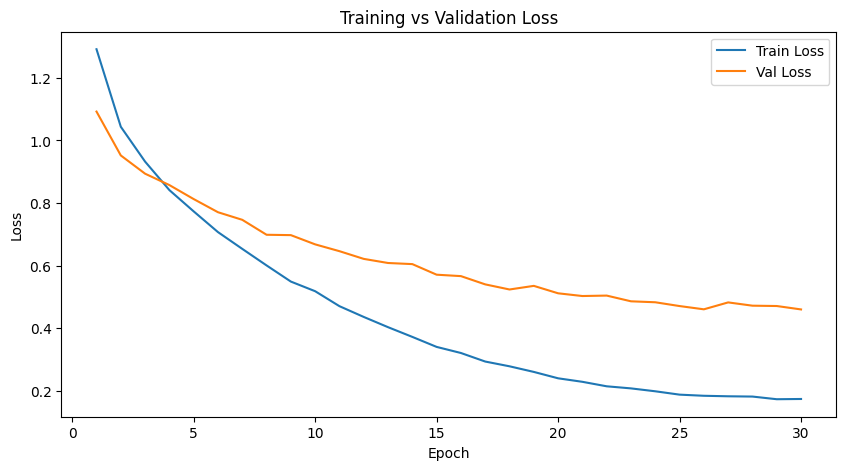

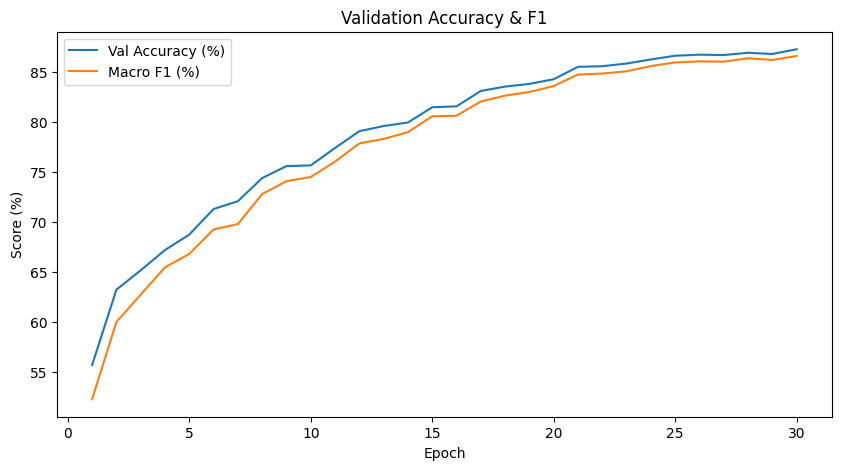

In [14]:
df = pd.read_csv("training_metrics.csv")

plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["val_acc"] * 100, label="Val Accuracy (%)")
plt.plot(df["epoch"], df["val_f1"] * 100, label="Macro F1 (%)")
plt.title("Validation Accuracy & F1")
plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.legend()
plt.show()


In [15]:
model = HybridPolyAttnClassifier(num_classes=len(full_ds.classes))  # adjust num_classes if different
model.backbone.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

In [16]:
ckpt_path = "./models/best_hybrid_gray_v1.pth"
model.load_state_dict(torch.load(ckpt_path, map_location="cuda" if torch.cuda.is_available() else "cpu"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"Loaded model from {ckpt_path}")

Loaded model from ./models/best_hybrid_gray_v1.pth


/tmp/ipykernel_9742/4008586895.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location="cuda" if torch.cuda.is_available

In [17]:
infer_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensure grayscale input
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),  # same as training normalization
])

In [66]:
img_path = "./test_data/nigger1.png"
img = Image.open(img_path).convert("L")  # convert to grayscale
tensor = infer_transform(img).unsqueeze(0).to(device)

In [67]:
with torch.no_grad():
    outputs, _ = model(tensor)
    probs = torch.softmax(outputs, dim=1)[0]
    pred_class = torch.argmax(probs).item()
    confidence = probs[pred_class].item()

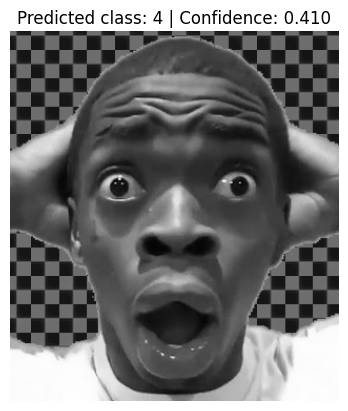

Predicted: suprise


In [68]:
plt.imshow(img, cmap="gray")
plt.title(f"Predicted class: {pred_class} | Confidence: {confidence:.3f}")
plt.axis("off")
plt.show()
classes = ["angry", "fear", "happy", "sad", "suprise",]
print("Predicted:", classes[pred_class])